<a href="https://colab.research.google.com/github/chuancao26/islp/blob/main/exercices_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Agregando Librerias

In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0b346fb1c8b632656d63e6d6d32ae2d8468cf76aa645a86bb282051572dab2f1
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ISLP import load_data
from ISLP.models import ModelSpec as MS
from ISLP.bart import BART

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
import sklearn.model_selection as skm



Vamos a desarrollar la parte practica

# 7

In [ ]:
boston = load_data("Boston")

In [ ]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


En este dataset, tenemos que aplicar Random Forest con determinadas configuraciones, la variable respuesta es *medv*

In [ ]:
# vamos a hacer los primeros seteos con el modelo
model = MS(boston.columns.drop("medv"))
D = model.fit_transform(boston)

feature_names = list(D.columns)

X = np.asarray(D)


In [ ]:
X_train, X_test, y_train, y_test = skm.train_test_split(X,
                                                        boston['medv'],
                                                        test_size=.3,
                                                        random_state=42)

In [ ]:
boston_rf = RandomForestRegressor(max_features=6, n_estimators=100).fit(X_train, y_train)
y_hat_rf = boston_rf.predict(X_test)
np.mean((y_test - y_hat_rf)**2)


np.float64(9.68399655921053)

Necesitamos hacer un grafico en el que mostramos la evoluacion del MSE respecto de variaciones en los parametros. Especificamente la cantidad de features y los n_estimators.

In [31]:
# haremos un gridsearch
params = {"n_estimators": [50, 100, 200 ,300 ,400 , 500],
          "max_features": np.arange(1, X_train.shape[1], 2)}

boston_rf = RandomForestRegressor(max_features=6,
                                  n_estimators=100,
                                  random_state=42)
kfold = skm.KFold(5,
                  random_state=42,
                  shuffle=True)
grid = skm.GridSearchCV(boston_rf,
                        param_grid=params,
                        scoring="neg_mean_squared_error",
                        n_jobs=-1,
                        verbose=2)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)





Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'max_features': np.int64(5), 'n_estimators': 50}
-12.867244527806843


In [32]:
results = pd.DataFrame(grid.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.147545,0.013876,0.011213,0.000524,1,50,"{'max_features': 1, 'n_estimators': 50}",-18.600030,-18.579454,-26.931981,-12.937813,-22.010979,-19.812051,4.599394,36
1,0.267375,0.005234,0.018335,0.000077,1,100,"{'max_features': 1, 'n_estimators': 100}",-15.901557,-16.530594,-25.377569,-11.995456,-21.295476,-18.220130,4.640336,35
2,0.562506,0.009543,0.038322,0.003717,1,200,"{'max_features': 1, 'n_estimators': 200}",-15.466094,-15.599550,-25.593289,-11.865030,-21.027403,-17.910273,4.829154,32
3,0.832740,0.013429,0.052416,0.001483,1,300,"{'max_features': 1, 'n_estimators': 300}",-15.894542,-15.077325,-26.096178,-12.512424,-21.110799,-18.138254,4.862470,34
4,1.275567,0.292233,0.084977,0.024162,1,400,"{'max_features': 1, 'n_estimators': 400}",-15.608374,-14.947483,-26.062199,-12.644868,-20.963633,-18.045311,4.847413,33


In [33]:
results = results[["param_max_features", "param_n_estimators", "mean_test_score"]]
results.head()

,param_max_features,param_n_estimators,mean_test_score
0,1,50,-19.812051
1,1,100,-18.220130
2,1,200,-17.910273
3,1,300,-18.138254
4,1,400,-18.045311


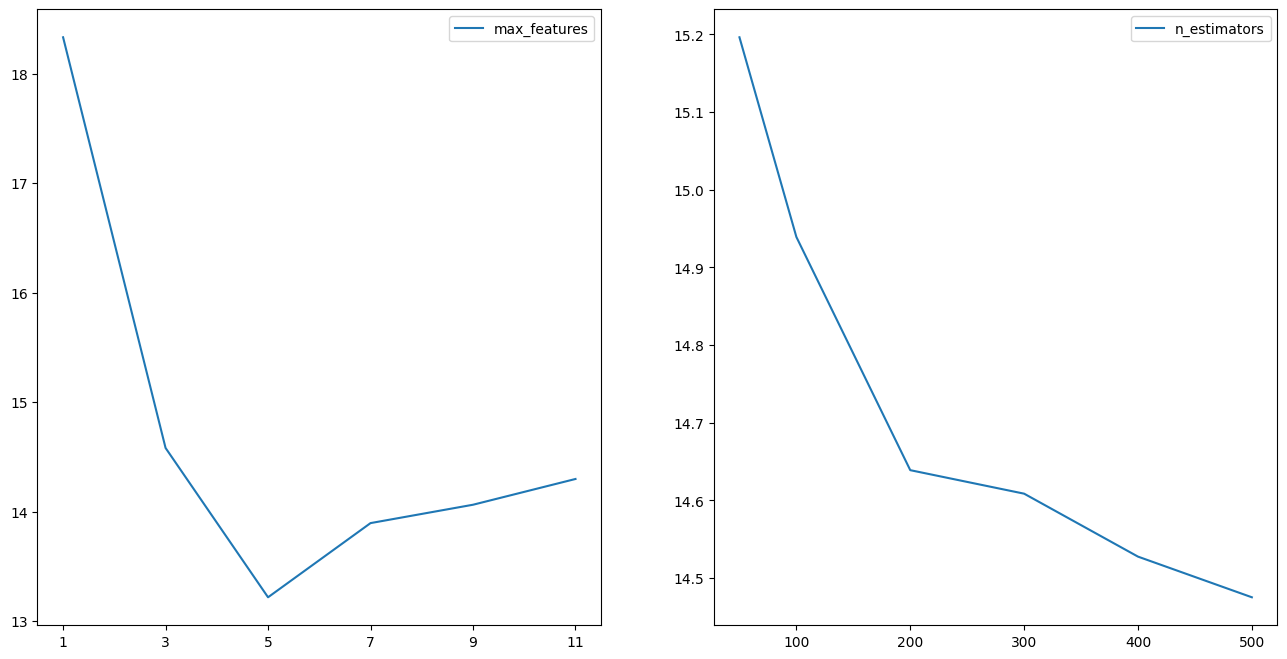

In [34]:
# vamos a graficar
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
data_features = results.groupby("param_max_features").mean()
ax[0].plot([str(i) for i in data_features.index], -data_features["mean_test_score"], label="max_features")
ax[0].legend()
data_estimators = results.groupby("param_n_estimators")["mean_test_score"].mean()
ax[1].plot(data_estimators.index, -data_estimators, label="n_estimators")
ax[1].legend()
plt.show()

In [ ]:
data_estimators = results.groupby("param_n_estimators")["mean_test_score"].mean()
data_estimators

,mean_test_score
param_n_estimators,
50,-15.112885
100,-14.720715
200,-14.431915
300,-14.341900
400,-14.254070
500,-14.220134


In [36]:
test_m_features = {}
max_n_estimators = 250

for max_feature in range(1, X_train.shape[1] + 1):
    test_m_features[max_feature] = []

    rf = RandomForestRegressor(n_estimators=1,
                               max_features=max_feature,
                               warm_start=True,
                               random_state=42)

    for estimator in range(1, max_n_estimators + 1):
        rf.n_estimators = estimator

        rf.fit(X_train, y_train)

        error = np.mean((y_test - rf.predict(X_test))**2)
        test_m_features[max_feature].append(error)

print("¡Terminado mucho más rápido!")

¡Terminado mucho más rápido!


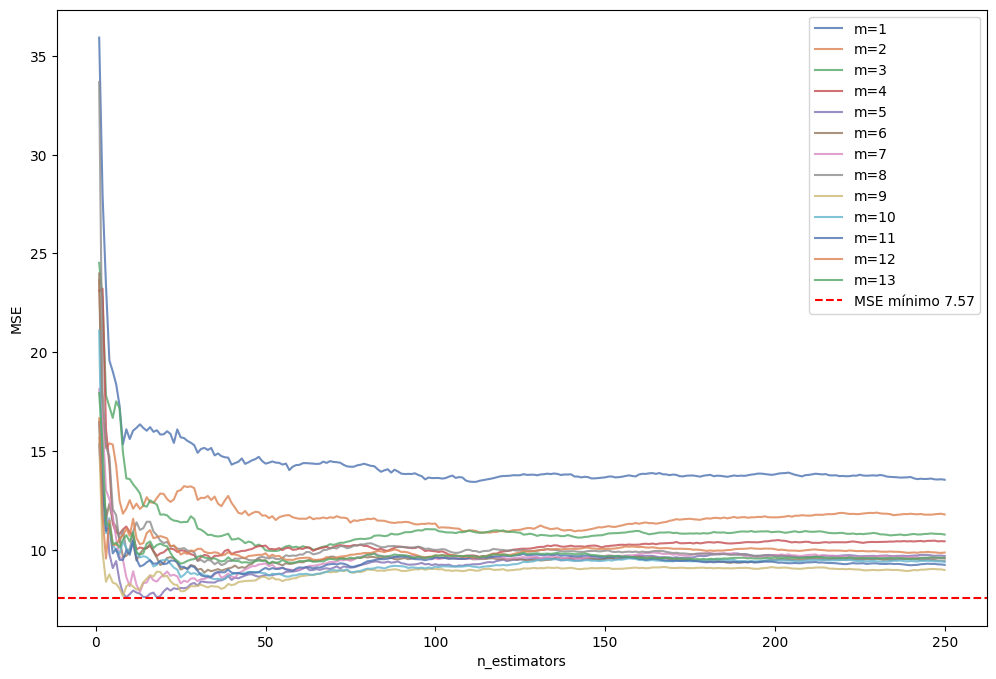

In [42]:
# ahora vamos a graficar
fig, ax = plt.subplots(figsize=(12,8))
palette = sns.color_palette("deep", len(test_m_features))

for key, value in test_m_features.items():
  sns.lineplot(x=np.arange(1, max_n_estimators + 1),
               y=value,
               label=f"m={key}",
               ax=ax,
               color=palette[key - 1],
               alpha=0.8)
min_mse = min([min(value) for value in test_m_features.values()])
ax.axhline(y=min_mse,
           color="red",
           linestyle="--",
           label=f"MSE mínimo {min_mse.round(2)}")
ax.legend()
ax.set_xlabel("n_estimators")
ax.set_ylabel("MSE")
plt.show()

Podemos apreciar que en la busqueda, el cambio de max_features hasta un valor de 5 representa una gran caida en el mse del modelo. El valor minimo de MSE obtenido fue con la configuracion de 5 como max_features y 25 de n_estimators.

# 8

Vamos a usar el data set Carseats, con un configuracion cuantitativa de la variable respuesta.


In [44]:
carseats = load_data("Carseats")
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## a)

In [74]:
# vamos a splitear la informacion
model = MS(carseats.columns.drop("Sales"), intercept=False)
D = model.fit_transform(carseats)

feature_names = list(D.columns)

X_train, X_test, y_train, y_test = skm.train_test_split(D,
                                                        carseats["Sales"],
                                                        test_size=.3,
                                                        random_state=42)


## b)


In [75]:
carseat_decision = DecisionTreeRegressor(max_depth=3,
                                          random_state=42).fit(X_train, y_train)

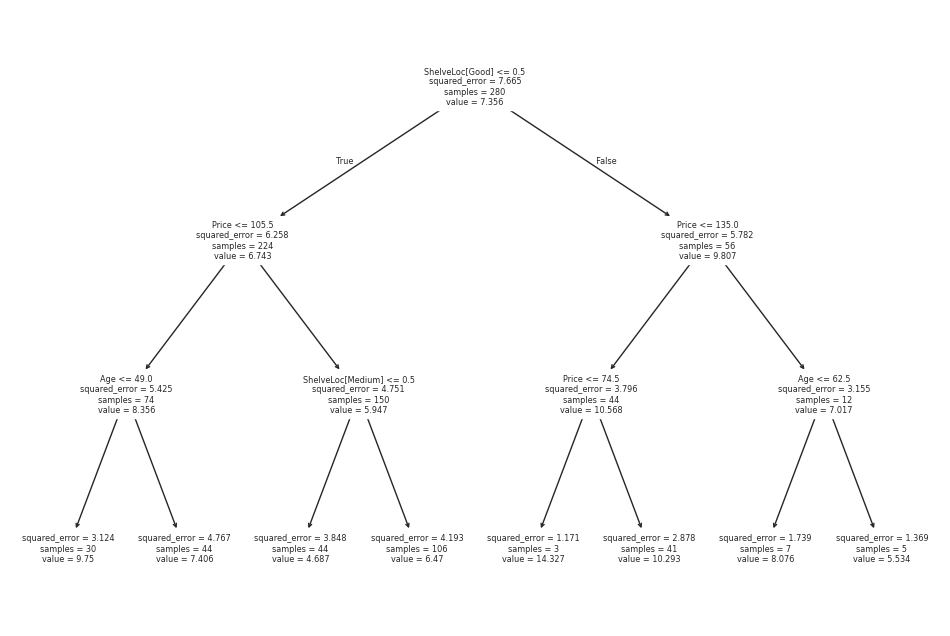

In [76]:
fig, ax = plt.subplots(figsize=(12,8))
plot_tree(carseat_decision, feature_names=feature_names, ax=ax);



In [77]:
y_hat_decision = carseat_decision.predict(X_test)
np.mean((y_test - y_hat_decision)**2)

np.float64(4.806952738698439)

Podemos apreciar que el modelo nos genera un arbol completo con los features, obteniendo un MSE de 4.80.

## c)

In [78]:
# ahora vamos a buscar el max_depth de forma inteligente teniendo en cuenta el MSE
params = {"max_depth": np.arange(1, 25)}
kfold = skm.KFold(5,
                  random_state=42,
                  shuffle=True)
search = skm.GridSearchCV(DecisionTreeRegressor(random_state=42),
                          param_grid=params,
                          scoring="neg_mean_squared_error",
                          cv=kfold,
                          n_jobs=-1,
                          verbose=2,
                          )
search.fit(X_train, y_train)
search.best_params_
print(f"un modelo con max_depth={search.best_params_} logra un mse={-search.best_score_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
un modelo con max_depth={'max_depth': np.int64(7)} logra un mse=4.444171042588506


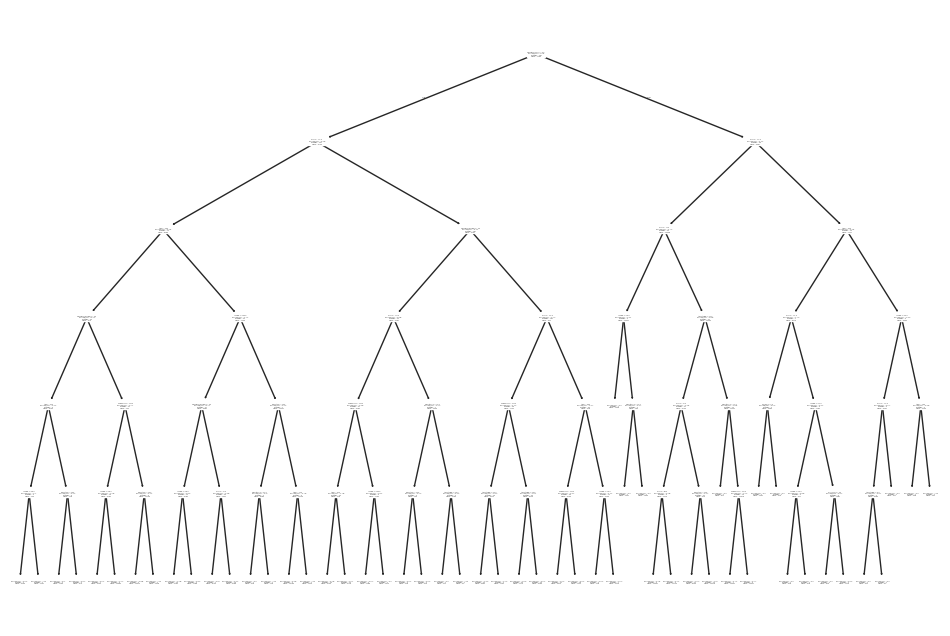

In [81]:
carseat_decision = DecisionTreeRegressor(max_depth=6,
                                          random_state=42).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(12,8))
plot_tree(carseat_decision, feature_names=feature_names, ax=ax);


In [82]:
alphas_decision = carseat_decision.cost_complexity_pruning_path(X_train, y_train)

params = {"ccp_alpha": alphas_decision["ccp_alphas"]}

search = skm.GridSearchCV(carseat_decision,
                          param_grid=params,
                          scoring="neg_mean_squared_error",
                          cv=kfold
                          )
search.fit(X_train, y_train)
print(f"el modelo con un alpha de {search.best_estimator_} logra un mse de {search.best_score_}")

el modelo con un alpha de DecisionTreeRegressor(ccp_alpha=np.float64(0.039531624000999147), max_depth=6,
                      random_state=42) logra un mse de -4.257458041475013


Podemos apreciar que en el caso del mejor modelo con max_depth de 6, al aplicarle podammiento podemos lograr reducir el MSE, sin embargo la mejora no es tan significativa.

Veamos si es que el arbol necesita podamiento.


In [63]:
decision = DecisionTreeRegressor(
                                random_state=42).fit(X_train, y_train)
alphas_decision = decision.cost_complexity_pruning_path(X_train, y_train)

# ahora hagamos la busqueda
params = {"ccp_alpha": alphas_decision["ccp_alphas"]}

search = skm.GridSearchCV(DecisionTreeRegressor(random_state=4),
                          param_grid=params,
                          scoring="neg_mean_squared_error",
                          cv=kfold
                          )
search.fit(X_train, y_train)
print(f"el modelo con un alpha de {search.best_estimator_} logra un mse de {search.best_score_}")

el modelo con un alpha de DecisionTreeRegressor(ccp_alpha=np.float64(0.05016071428571419), random_state=4) logra un mse de -4.21064054339231


Podemos apreciar que la estrategia con el podamiento logra tener un mse menor que el encontrado con una busqueda del mejor max_depth. Sin embargo, esta mejora no es tan significativa.

## d)

In [83]:
# ahora vamos a desarrollar el bagging aproach
carseat_bagging = RandomForestRegressor(max_features=X_train.shape[1],
                                        random_state=42).fit(X_train, y_train)
y_hat_bagging = carseat_bagging.predict(X_test)
np.mean((y_test - y_hat_bagging)**2)

np.float64(2.534683515)

/tmp/ipython-input-1071293387.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


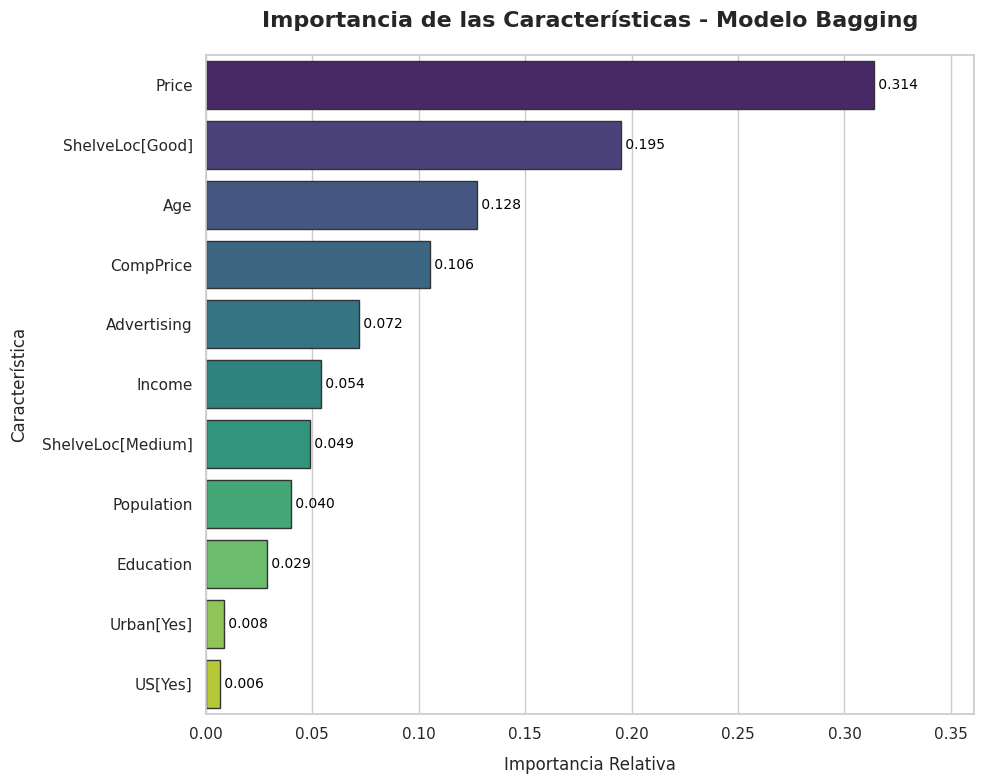

In [84]:
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': carseat_bagging.feature_importances_
})

importances_df = importances_df.sort_values(by='Importance', ascending=False)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))


barplot = sns.barplot(
    data=importances_df,
    x='Importance', #
    y='Feature',
    palette='viridis',
    edgecolor='.2'
)


plt.title('Importancia de las Características - Modelo Bagging', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa', fontsize=12, labelpad=10)
plt.ylabel('Característica', fontsize=12, labelpad=10)


for index, value in enumerate(importances_df['Importance']):
    plt.text(value, index, f' {value:.3f}', va='center', ha='left', fontsize=10, color='black')

# Ajustamos el límite derecho del eje X para dar espacio al texto de los valores
plt.xlim(right=importances_df['Importance'].max() * 1.15)


plt.tight_layout()
plt.show()

Podemos apreciar que la variable mas importante es Price, la cual ha sido mas usada como corte en los arboles generados por random forest en configuracion de bagging

## e)

In [85]:
# vamos a buscar la mejor configuracion de max_features

carseat_rf = RandomForestRegressor(random_state=42)

params = {"max_features": np.arange(1, X_train.shape[1] + 1)}

search = skm.GridSearchCV(carseat_rf,
                          param_grid=params,
                          cv=kfold,
                          scoring="neg_mean_squared_error")

search.fit(X_train, y_train)
print(f"con un configuracion de max_features={search.best_estimator_} tenemos un mse={search.best_score_}")

con un configuracion de max_features=RandomForestRegressor(max_features=np.int64(10), random_state=42) tenemos un mse=-2.614547239607141


In [86]:
carseat_rf = RandomForestRegressor(max_features=10, random_state=42).fit(X_train, y_train)
y_hat_rf = carseat_rf.predict(X_test)
np.mean((y_test - y_hat_rf)**2)

np.float64(2.463991149833332)

/tmp/ipython-input-2810757679.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


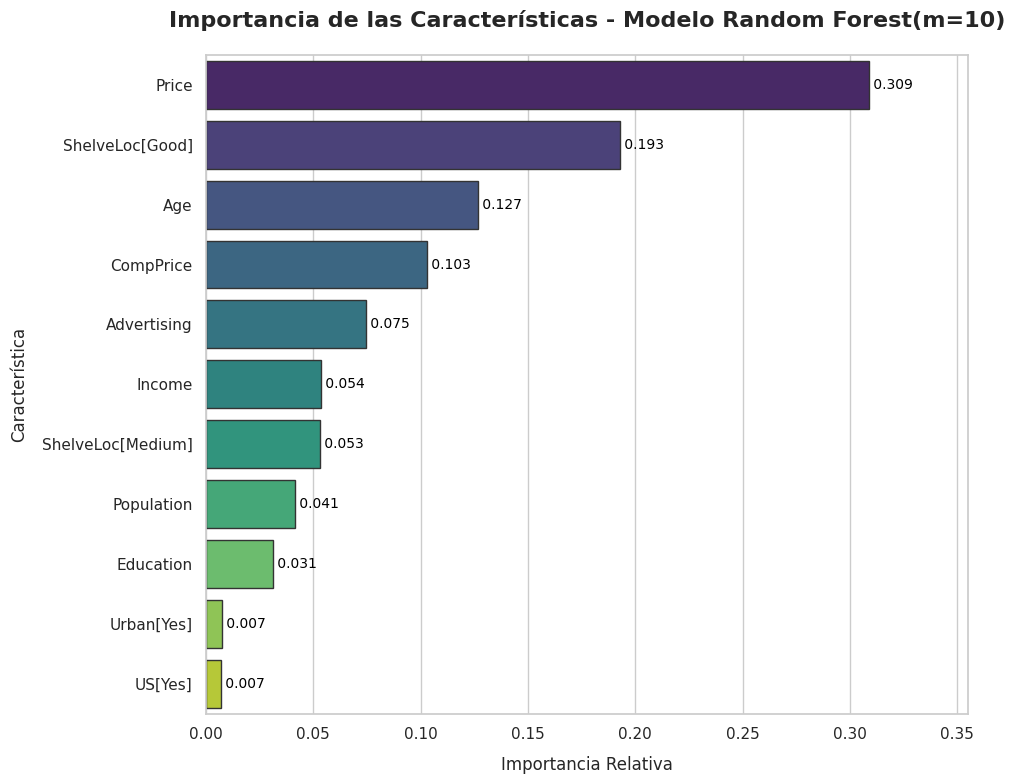

In [88]:

importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': carseat_rf.feature_importances_
})

importances_df = importances_df.sort_values(by='Importance', ascending=False)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))


barplot = sns.barplot(
    data=importances_df,
    x='Importance', #
    y='Feature',
    palette='viridis',
    edgecolor='.2'
)


plt.title('Importancia de las Características - Modelo Random Forest(m=10)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa', fontsize=12, labelpad=10)
plt.ylabel('Característica', fontsize=12, labelpad=10)


for index, value in enumerate(importances_df['Importance']):
    plt.text(value, index, f' {value:.3f}', va='center', ha='left', fontsize=10, color='black')

# Ajustamos el límite derecho del eje X para dar espacio al texto de los valores
plt.xlim(right=importances_df['Importance'].max() * 1.15)


plt.tight_layout()
plt.show()

In [96]:
results = pd.DataFrame(search.cv_results_)
results = results[["param_max_features", "mean_test_score"]]
results["mean_test_score"] = -results["mean_test_score"]

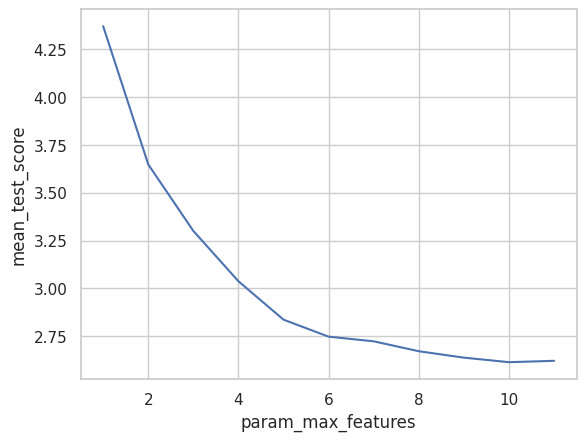

In [97]:
sns.lineplot(data=results, x="param_max_features", y="mean_test_score")
plt.show()

Podemos apreciar que el Random Forest logra una reduccion grande hasta los 6 de max_features.

## f)

In [99]:
carseat_bart = BART(burnin=100, ndraw=1000,
                    random_state=42).fit(X_train, y_train)
y_hat_bart = carseat_bart.predict(X_test)
np.mean((y_test - y_hat_bart)**2)

np.float64(1.2440141807904748)